# Path Tracing Notebook
Implementation of Light Transport Algorithms

********************************************************************************************

In [1]:
import os
os.chdir("..")
print(os.getcwd())

/Volumes/Work/Projects/Rendering/light-transport-simulator


In [2]:
import taichi as ti
ti.init(arch=ti.cpu, debug=True, random_seed=68739)

[Taichi] version 1.7.3, llvm 15.0.7, commit 5ec301be, osx, python 3.11.11
[Taichi] Starting on arch=arm64


[I 03/17/25 22:38:33.299 14822272] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [3]:
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from taichi.math import vec3, cross, normalize, dot

In [4]:
cornell_box = "scenes/cornell-box.pbrt"
volumetric_caustic = "scenes/volumetric-caustic.pbrt"
door_scene = "scenes/veach/veach-ajar.pbrt"
testball ="scenes/material-testball/scene-v4.pbrt"
one = "scenes/one.pbrt"
cb = "scenes/cb.pbrt"
cb_spheres = "scenes/cb-spheres.pbrt"
cb_spheres_flipped = "scenes/cb-spheres-2.pbrt"
veach_mis = "scenes/veach-mis/scene-v4.pbrt"
rough_metal_spheres = "scenes/cb-rough-metal.pbrt"


file_path = cb_spheres

In [5]:
from primitives.primitives import Primitive

n_p = 1024
PS = ti.root.dense(ti.i, n_p)
primitives = Primitive.field()
PS.place(primitives)

<ti.SNode of type dense>

In [6]:
from pbrt.transformations import parse_transform
from pbrt.material_parser import parse_materials
from pbrt.shape_parser import extract_all_shapes, parse_shapes
from pbrt.parser import pbrt_to_dict

# Parse the scene
scene_dict = pbrt_to_dict(file_path)

# Get the Transform Matrix
global_transform = parse_transform(scene_dict["Transform"])

# Extract the shapes
shapes_list = extract_all_shapes(file_path)

# Parse the materials
materials = scene_dict.get("MakeNamedMaterial", [])
# parsed_materials = parse_materials(materials)

# Extract Primitives
n_primitives, light_count = parse_shapes(shapes_list, materials, primitives, global_transform)

In [7]:
n_primitives, light_count

(14, 2)

In [8]:
primitives[11].material.reflectance

[1. 1. 1.]

In [9]:
from base.lights import DiffuseAreaLight

# Create a Taichi field for light sources
n_lights = light_count
LS = ti.root.dense(ti.i, n_lights)
lights = DiffuseAreaLight.field()
LS.place(lights)

<ti.SNode of type dense>

In [10]:
@ti.kernel
def populate_shapes():

    for i in range(n_primitives):

        # primitives[i].bsdf.diffuse.type = 0
        # primitives[i].bsdf.transmit.type = 1
        # primitives[i].bsdf.dielectric.type = 2
        # primitives[i].bsdf.conductor.type = 3

        material = primitives[i].material

        if material.material_type==0:
            # Diffuse material
            primitives[i].bsdf.add_diffuse(material.reflectance)
        elif material.material_type==1:
            # Diffuse-Transmission material
            primitives[i].bsdf.add_transmission(material.reflectance, material.transmittance)
        elif material.material_type==2:
            # Dielectric material
            primitives[i].bsdf.add_dielectric(material.eta[0], material.reflectance, material.uroughness, material.vroughness)
        elif material.material_type==3:
            # Conductor material
            print(material.eta)
            primitives[i].bsdf.add_conductor(material.eta, material.k, material.uroughness, material.vroughness)

        if primitives[i].is_light == 1:
            print(i, primitives[i].material.emission)
            light_idx = primitives[i].light_idx
            lights[light_idx].shape_idx = i  # Link the light to the primitive
            lights[light_idx].two_sided = 0  # Assuming lights are one-sided
            lights[light_idx].Le = primitives[i].material.emission
            light_idx += 1

populate_shapes()

0.000000 0.000000
[0.200438, 0.924033, 1.102212]
12 [17.000000, 12.000000, 4.000000]
13 [17.000000, 12.000000, 4.000000]


In [11]:
lights.to_numpy()

{'shape_idx': array([12, 13], dtype=int32),
 'Le': array([[17., 12.,  4.],
        [17., 12.,  4.]], dtype=float32),
 'two_sided': array([0, 0], dtype=int32)}

In [12]:
from primitives.aabb import AABB, BVHPrimitive

# Enclose all the primitives in their individual axis-aligned bounding boxes (AABB)
BS = ti.root.dense(ti.i, n_primitives)
bvh_primitives = BVHPrimitive.field()
BS.place(bvh_primitives)

scene_min = ti.Vector.field(3, dtype=ti.f32, shape=())  # Global min bounds
scene_max = ti.Vector.field(3, dtype=ti.f32, shape=())  # Global max bounds

@ti.kernel
def init_bounded_boxes():
    # Initialize scene bounding box with extreme values
    scene_min[None] = vec3(1e10, 1e10, 1e10)
    scene_max[None] = vec3(-1e10, -1e10, -1e10)

    for i in ti.ndrange(n_primitives):
        bvh_primitives[i].prim = primitives[i]
        bvh_primitives[i].prim_num = i

        # Get primitive bounds
        min_p, max_p = primitives[i].get_bounds()
        centroid = (min_p + max_p) * 0.5
        bvh_primitives[i].bounds = AABB(min_point=min_p, max_point=max_p, centroid=centroid)

        # Update scene-wide bounding box
        for j in range(3):  # Loop over x, y, z components
            scene_min[None][j] = min(scene_min[None][j], min_p[j])
            scene_max[None][j] = max(scene_max[None][j], max_p[j])


init_bounded_boxes()

bvh_primitives.shape[0], n_primitives

(14, 14)

In [13]:
OPS = ti.root.dense(ti.i, n_primitives)
ordered_prims = Primitive.field()
OPS.place(ordered_prims)

<ti.SNode of type dense>

In [14]:
from accelerators.bvh import BVHNode, BucketInfo

node_idx = 0

BVS = ti.root.dense(ti.i, 3 * n_primitives)
nodes = BVHNode.field()
BVS.place(nodes)


<ti.SNode of type dense>

In [15]:
nodes.shape[0]

42

In [16]:
total_nodes = ti.field(ti.i32, shape=())
split_method = ti.field(ti.i32, shape=())
start = ti.field(ti.i32, shape=())
end = ti.field(ti.i32, shape=())
ordered_prims_idx = ti.field(ti.i32, shape=())
stack_ptr = ti.field(ti.i32, shape=())
# ordered_prims_size = ti.field(ti.i32, shape=())

@ti.kernel
def init_stack():
    total_nodes[None] = 0
    split_method[None] = 0
    start[None] = 0
    end[None] = n_primitives
    ordered_prims_idx[None] = 0
    stack_ptr[None] = 0
    # ordered_prims_size[None] = 0

init_stack()

In [17]:
stack = ti.field(ti.i32, shape=(3*n_primitives, 4))
n_buckets = 12
buckets = BucketInfo.field(shape=(n_buckets))
costs = ti.field(dtype=ti.f32, shape=(n_buckets-1))

In [18]:
from accelerators.bvh import build_bvh

start_t = time.time()

build_bvh(primitives, bvh_primitives, start, end, ordered_prims, nodes, total_nodes, split_method, stack, stack_ptr, ordered_prims_idx, costs, buckets)

end_t = time.time()

In [19]:
# total_nodes = ti.field(ti.i32, shape=())
# split_method = ti.field(ti.i32, shape=())
# start = ti.field(ti.i32, shape=())
# end = ti.field(ti.i32, shape=())
# ordered_prims_idx = ti.field(ti.i32, shape=())
# stack_ptr = ti.field(ti.i32, shape=())
# max_prims_in_node = ti.field(ti.i32, shape=())
# # ordered_prims_size = ti.field(ti.i32, shape=())
#
# @ti.kernel
# def init_stack():
#     total_nodes[None] = 0
#     split_method[None] = 0
#     start[None] = 0
#     end[None] = n_primitives
#     ordered_prims_idx[None] = 0
#     stack_ptr[None] = 0
#     max_prims_in_node[None] = 4
#
# init_stack()

In [20]:
# stack = ti.field(ti.i32, shape=(3*n_primitives, 4))
# n_buckets = 12
# buckets = BucketInfo.field(shape=(n_buckets))
# costs = ti.field(dtype=ti.f32, shape=(n_buckets-1))

In [21]:
# from accelerators.hlbvh import build_hlbvh
# from accelerators.bvh import build_bvh
#
# start_t = time.time()
#
# root = ti.field(ti.i32, shape=())
#
# build_hlbvh(
#     primitives,
#     bvh_primitives,
#     ordered_prims,
#     n_primitives,       # number of actual primitives
#     nodes,
#     total_nodes,
#     ordered_prims_idx,  # you already have this
#     max_prims_in_node,
#     root
# )
#
# end_t = time.time()

In [22]:
print("Elapsed (with compilation) = %s" % (end_t - start_t))
print(f"Total Nodes: {total_nodes}")

Elapsed (with compilation) = 1.284121036529541
Total Nodes: 23


In [23]:
from tests.test_bvh import print_bvh

print_bvh(nodes, total_nodes[None])

BVHNode 0 [Interior]: split_axis = 1 child_0 = 1 child_1 = 14 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 1 [Interior]: split_axis = 1 child_0 = 2 child_1 = 7 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 2 [Interior]: split_axis = 1 child_0 = 3 child_1 = 4 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 3 [Leaf]: first_prim_offset = 0 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
BVHNode 4 [Interior]: split_axis = 1 child_0 = 5 child_1 = 6 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 5 [Leaf]: first_prim_offset = 1 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
BVHNode 6 [Leaf]: first_prim_offset = 2 n_primitives = 1 bounds = (min: [-1.000000, 1.000000, 5.800000] , max: 

In [24]:
from tests.test_bvh import test_bvh
max_nodes = n_primitives
debug_stack = ti.field(dtype=ti.i32, shape=(max_nodes,))
debug_ptr = ti.field(dtype=ti.i32, shape=(1,))
error_count = ti.field(dtype=ti.i32, shape=(1,))

test_bvh(nodes, debug_stack, debug_ptr, error_count)

BVH test error count = 0


In [25]:
from accelerators.bvh import LinearBVHNode
from accelerators.bvh import flatten_bvh

# create a linear representation of the bvh tree (empty)

LBVS = ti.root.dense(ti.i, total_nodes[None])
linear_bvh = LinearBVHNode.field()
LBVS.place(linear_bvh)

stack_size = 2 * n_primitives - 1  # Maximum possible stack size
stack3 = ti.Vector.field(3, dtype=ti.i32, shape=stack_size)
stack_top_2 = ti.field(dtype=ti.i32, shape=())

start_t = time.time()
total_nodes = flatten_bvh(nodes, linear_bvh, 0, stack3, stack_top_2)
end_t = time.time()
print(f"Total flattened nodes: {total_nodes}")

Total flattened nodes: 23


In [26]:
linear_bvh[0].second_child_offset

14

In [27]:
print("Elapsed (with compilation) = %s" % (end_t - start_t))

Elapsed (with compilation) = 0.07885098457336426


In [28]:
from tests.test_linear_bvh import print_flattened_bvh

print_flattened_bvh(linear_bvh, total_nodes)

LinearBVHNode 0 [Interior]: axis = 1 second_child_offset = 14 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 1 [Interior]: axis = 1 second_child_offset = 7 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 2 [Interior]: axis = 1 second_child_offset = 4 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 3 [Leaf]: primitives_offset = 0 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
LinearBVHNode 4 [Interior]: axis = 1 second_child_offset = 6 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 5 [Leaf]: primitives_offset = 1 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
LinearBVHNode 6 [Leaf]: primitives_offset = 2 n_primitives = 1 bounds = (min: [-1.000000, 1.000000,

In [29]:
from tests.test_linear_bvh import test_flattened_bvh

max_nodes = n_primitives
debug_stack = ti.field(dtype=ti.i32, shape=(max_nodes,))
debug_ptr = ti.field(dtype=ti.i32, shape=(1,))
error_count = ti.field(dtype=ti.i32, shape=(1,))

test_flattened_bvh(linear_bvh, debug_stack, debug_ptr, error_count)

Flattened BVH test error count = 0


In [30]:
# Parse Camera Data

camera_data = scene_dict["Camera"][0]["properties"]
camera_data

{'fov': [19.5]}

In [31]:
scene_min[None], scene_max[None]

([-1.         -1.00000012  5.80000019], [1.         1.         7.80000019])

In [32]:
from pbrt.camera_parser import extract_camera_from_scene
from base.camera import auto_fit_camera, get_camera

eye, center, up, fov = extract_camera_from_scene(scene_dict)

# camera = auto_fit_camera(scene_min[None], scene_max[None], fov, 400, 400, 0)
camera = get_camera(eye, center, up, fov, 40, 40)

Extracted Camera Parameters: [-0.000000, -0.000000, -0.000000] [0.000000, 0.000000, 1.000000] [-0.000000, 1.000000, -0.000000] 19.500000
[-0.000000, -0.000000, -0.000000] [0.000000, 0.000000, 1.000000] [-0.000000, 1.000000, -0.000000]


In [33]:
camera

{'width': 40, 'height': 40, 'position': [-0.0, -0.0, -0.0], 'frame': {'x': [1.0, 0.0, -0.0], 'y': [-0.0, 1.0, 0.0], 'z': [-0.0, -0.0, -1.0]}, 'fov': 19.5, 'aspect_ratio': 1.0, 'lens_radius': 0.0, 'focal_distance': 1.0, 'screen_window': [-0.1718314290046692, 0.1718314290046692, -0.1718314290046692, 0.1718314290046692], 'dx_camera': [0.00859157182276249, 0.0, 0.0], 'dy_camera': [0.0, 0.00859157182276249, 0.0]}

In [34]:
scene_min[None], scene_max[None]

([-1.         -1.00000012  5.80000019], [1.         1.         7.80000019])

In [35]:
camera.frame

{'x': [1.0, 0.0, -0.0], 'y': [-0.0, 1.0, 0.0], 'z': [-0.0, -0.0, -1.0]}

In [36]:
@ti.kernel
def test_camera():
    # Generate a ray
    s, t = 0.5, 0.5  # Center of the screen
    ray_origin, ray_dir, rx_origin, rx_dir, ry_origin, ry_dir = camera.generate_ray_differential(s, t)
    print(ray_origin, ray_dir, rx_origin, rx_dir, ry_origin, ry_dir)

test_camera()

[0.000000, 0.000000, 0.000000] [0.000000, 0.000000, 1.000000] [0.000000, 0.000000, 0.000000] [0.008591, 0.000000, 0.999963] [0.000000, 0.000000, 0.000000] [0.000000, 0.008591, 0.999963]


In [37]:
from base.scene import Scene

pt = 0
mis = 1

# Instantiate a Scene object with the Camera object
scene = Scene(integrator=mis, spp=10, max_depth=7, sample_lights=1, sample_bsdf=1)

In [38]:
from base.render import render

# Initialize the image field outside the kernel using the actual values
image = ti.Vector.field(3, dtype=ti.f32, shape=(camera.width, camera.height))


start_t = time.time()

# Call the render_scene kernel
render(scene, image, lights, camera, ordered_prims, linear_bvh)

end_t = time.time()

print("Elapsed (with compilation) = %s" % (end_t - start_t))

Elapsed (with compilation) = 70.42526483535767


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..11.992057].


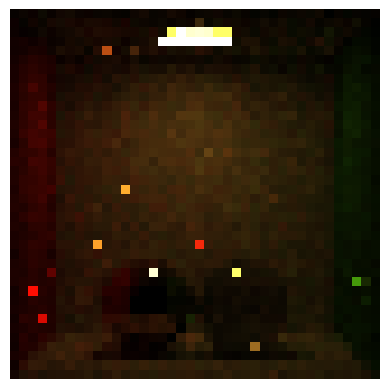

In [39]:
image_np = image.to_numpy()
# if np.isnan(image_np).any() or np.isinf(image_np).any():
#     print("Warning: NaN or Inf values detected in the image")
# image_np = np.clip(image_np, 0, 1)  # Clip values between 0 and 1
plt.imshow(image_np)
plt.axis('off')
plt.show()

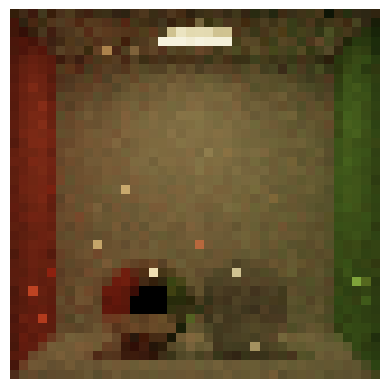

In [40]:
def tone_mapping(hdr_image, gamma=2.2):
    ldr_image = hdr_image / (1.0 + hdr_image)
    ldr_image = np.power(ldr_image, 1.0 / gamma)
    return np.clip(ldr_image, 0, 1)

ldr_image = tone_mapping(image_np)

# Display the tone-mapped image
plt.imshow(ldr_image)
plt.axis('off')
plt.show()